<div style="background: linear-gradient(135deg, #1a0533, #0d1b6e); padding: 44px 32px; border-radius: 18px; text-align: center; font-family: 'Segoe UI', sans-serif; border: 1px solid rgba(167,139,250,0.25);">
  <h1 style="color: #f0abfc; font-size: 2.6rem; margin-bottom: 10px; letter-spacing: 1px;">🧠 Emotion Detection from Text</h1>
  <p style="color: #a78bfa; font-size: 1.1rem; margin-bottom: 24px;">An end-to-end NLP pipeline to classify emotions using TF-IDF features and a LinearSVC model</p>
  <hr style="border: none; border-top: 1px solid rgba(167,139,250,0.3); margin: 18px 0;">
  <table style="margin: 0 auto; color: #c4b5fd; font-size: 0.92rem; border-collapse: separate; border-spacing: 8px 6px;">
    <tr>
      <td style="padding: 4px 20px; background: rgba(124,58,237,0.15); border-radius: 6px;"><b>👤 Author</b></td>
      <td style="padding: 4px 20px; background: rgba(124,58,237,0.08); border-radius: 6px;">kananiisha</td>
    </tr>
    <tr>
      <td style="padding: 4px 20px; background: rgba(124,58,237,0.15); border-radius: 6px;"><b>📁 Dataset</b></td>
      <td style="padding: 4px 20px; background: rgba(124,58,237,0.08); border-radius: 6px;">train.txt · val.txt · test.txt</td>
    </tr>
    <tr>
      <td style="padding: 4px 20px; background: rgba(124,58,237,0.15); border-radius: 6px;"><b>🤖 Model</b></td>
      <td style="padding: 4px 20px; background: rgba(124,58,237,0.08); border-radius: 6px;">LinearSVC → CalibratedClassifierCV + TF-IDF</td>
    </tr>
    <tr>
      <td style="padding: 4px 20px; background: rgba(124,58,237,0.15); border-radius: 6px;"><b>🏷️ Emotions</b></td>
      <td style="padding: 4px 20px; background: rgba(124,58,237,0.08); border-radius: 6px;">anger · fear · joy · love · sadness · surprise</td>
    </tr>
    <tr>
      <td style="padding: 4px 20px; background: rgba(124,58,237,0.15); border-radius: 6px;"><b>🎯 Val Accuracy</b></td>
      <td style="padding: 4px 20px; background: rgba(124,58,237,0.08); border-radius: 6px;">~90.90%</td>
    </tr>
  </table>

  <div style="margin-top: 28px; background: rgba(15,12,41,0.6); border-radius: 12px; padding: 16px 24px; display: inline-block; text-align: left; color: #c4b5fd; font-size: 0.88rem; font-family: monospace;">
    Raw Text &nbsp;→&nbsp; Preprocessing &nbsp;→&nbsp; TF-IDF &nbsp;→&nbsp; LinearSVC &nbsp;→&nbsp; <span style="color: #f0abfc;">Emotion Label</span>
  </div>
</div>

---

## 📋 Table of Contents

| # | Section |
|---|-----------------------------|
| 1 | [Title & Introduction](#1----title--introduction) |
| 2 | [Imports & Config](#2----imports--config) |
| 3 | [Data Loading & EDA](#3----data-loading--eda) |
| 4 | [Preprocessing](#4----preprocessing) |
| 5 | [Feature Engineering (TF-IDF)](#5----feature-engineering-tf-idf) |
| 6 | [Model Training & Comparison](#6----model-training--comparison) |
| 7 | [Evaluation & Visualizations](#7----evaluation--visualizations) |
| 8 | [Save Model & Conclusions](#8----save-model--conclusions) |

---
## 1 — Title & Introduction

### 🎯 Project Goal
Automatically detect the **emotion** expressed in a sentence and classify it into one of six classes:
`anger`, `fear`, `joy`, `love`, `sadness`, or `surprise`.

This is a **multi-class text classification** problem solved with classical NLP — no deep learning required.

### 📂 Dataset
Three pre-split files in semicolon-delimited format (`text;emotion`):

| Split | File | Samples |
|-------|------|---------|
| Train | `train.txt` | 16,000 |
| Validation | `val.txt` | 2,000 |
| Test | `test.txt` | 2,000 |

### 🏗️ Tech Stack

| Layer | Technology |
|-------|------------|
| Data handling | `pandas`, `numpy` |
| Text preprocessing | `nltk` (stopwords), `string` |
| Feature engineering | `TfidfVectorizer` (scikit-learn) |
| Models | `LinearSVC`, `LogisticRegression`, `MultinomialNB` |
| Calibration | `CalibratedClassifierCV` |
| Evaluation | `classification_report`, `confusion_matrix` |
| Serialisation | `pickle` |
| Visualisation | `matplotlib`, `seaborn` |

---
## 2 — Imports & Config

All third-party imports in **one cell**. A fixed random seed and file-path constants are defined here so every downstream cell is reproducible and easy to reconfigure.

In [14]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import string
import pickle
import warnings
warnings.filterwarnings('ignore')

# ── Data ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# ── ML ────────────────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Reproducibility & paths ───────────────────────────────────────────────────
RANDOM_SEED   = 42
np.random.seed(RANDOM_SEED)

TRAIN_PATH    = "train.txt"
VAL_PATH      = "val.txt"
TEST_PATH     = "test.txt"
MODEL_PATH    = "model.pkl"
VEC_PATH      = "vectorizer.pkl"
VAL_ACC_PATH  = "val_accuracy.txt"

# ── Dark theme for all plots ──────────────────────────────────────────────────
COLORS = ['#7c3aed', '#2563eb', '#0891b2', '#f0abfc', '#a78bfa', '#67e8f9']

plt.rcParams.update({
    'figure.facecolor' : '#0f0c29',
    'axes.facecolor'   : '#1a1040',
    'axes.edgecolor'   : '#7c3aed',
    'axes.labelcolor'  : '#c4b5fd',
    'xtick.color'      : '#c4b5fd',
    'ytick.color'      : '#c4b5fd',
    'text.color'       : '#f0abfc',
    'grid.color'       : '#2d1b69',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'legend.facecolor' : '#1a1040',
    'legend.edgecolor' : '#7c3aed',
})

print("✅ All libraries imported successfully.")
print(f"   pandas  {pd.__version__}  |  numpy  {np.__version__}  |  sklearn  imported")

✅ All libraries imported successfully.
   pandas  2.2.3  |  numpy  2.1.3  |  sklearn  imported


---
## 3 — Data Loading & EDA

Load all three splits, inspect sizes, check for nulls, plot the **class distribution bar chart**, and visualise the **text-length histogram** per emotion.

In [15]:
# ── Load all splits ───────────────────────────────────────────────────────────
train_df = pd.read_csv(TRAIN_PATH, sep=';', names=['text', 'emotion'])
val_df   = pd.read_csv(VAL_PATH,   sep=';', names=['text', 'emotion'])
test_df  = pd.read_csv(TEST_PATH,  sep=';', names=['text', 'emotion'])

print("📊 Dataset sizes")
print(f"   Train : {len(train_df):>6,} rows")
print(f"   Val   : {len(val_df):>6,} rows")
print(f"   Test  : {len(test_df):>6,} rows")
print()
print("🔍 Missing values in train:")
print(train_df.isnull().sum())
print()

train_df.head(8)

📊 Dataset sizes
   Train : 16,000 rows
   Val   :  2,000 rows
   Test  :  2,000 rows

🔍 Missing values in train:
text       0
emotion    0
dtype: int64



,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear


📌 Emotion distribution (training set):
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572



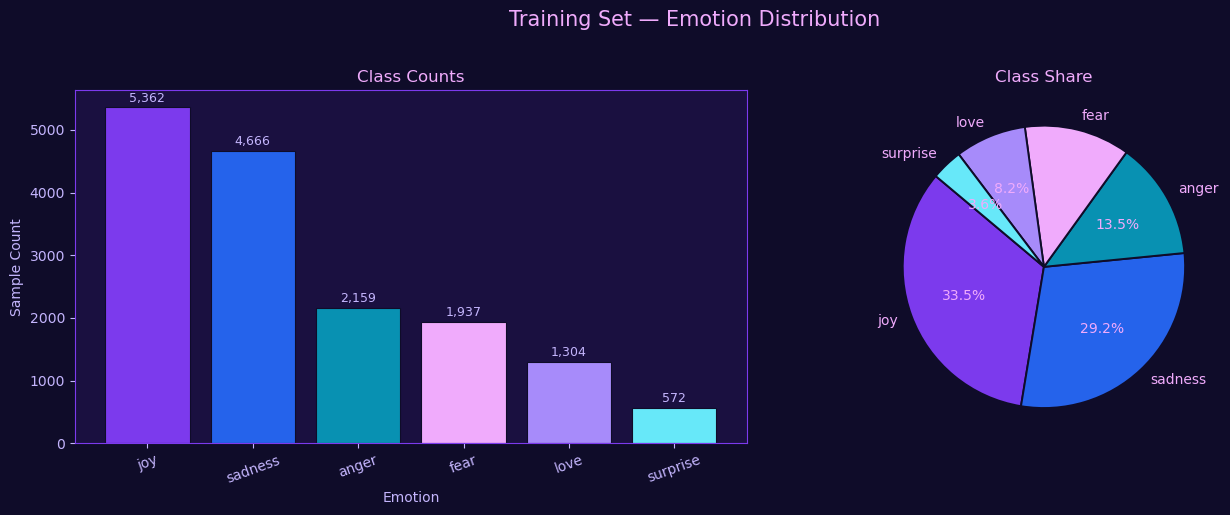

In [16]:
# ── Class distribution bar chart ──────────────────────────────────────────────
counts = train_df['emotion'].value_counts()

print("📌 Emotion distribution (training set):")
print(counts.to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Set — Emotion Distribution', fontsize=15, y=1.02)

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=COLORS, edgecolor='#0f0c29', linewidth=0.8)
axes[0].set_title('Class Counts')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Sample Count')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
                 f'{val:,}', ha='center', va='bottom', fontsize=9, color='#c4b5fd')

# Pie chart
axes[1].pie(
    counts.values, labels=counts.index, colors=COLORS,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': '#0f0c29', 'linewidth': 1.4}
)
axes[1].set_title('Class Share')

plt.tight_layout()
plt.show()

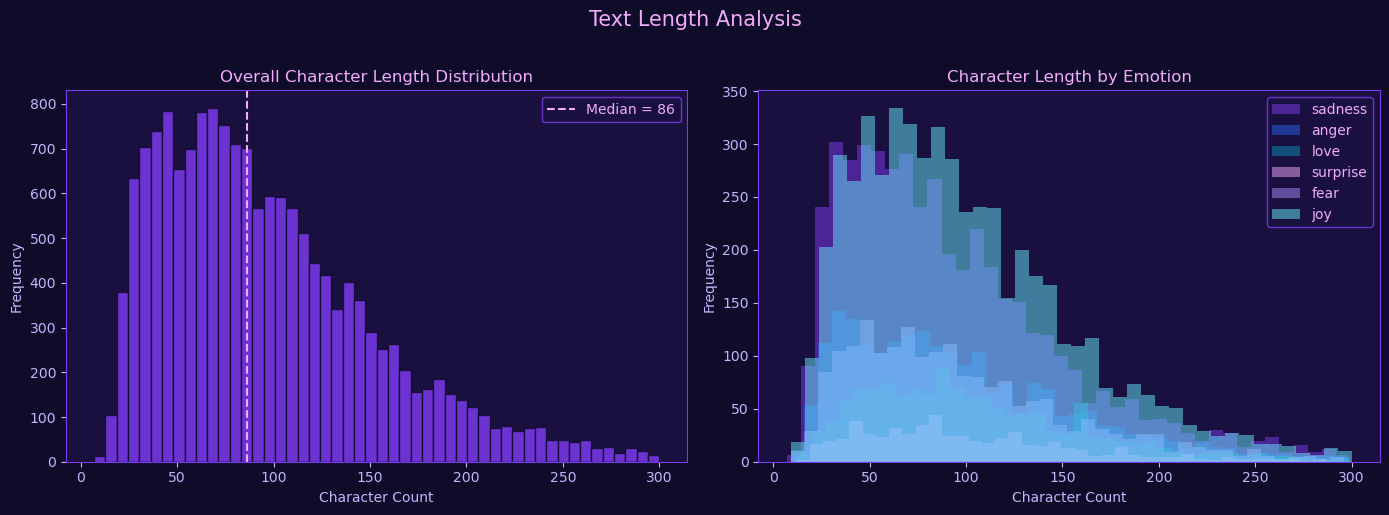

📏 Text length stats (train):
count    16000.0
mean        96.8
std         55.9
min          7.0
25%         53.0
50%         86.0
75%        129.0
max        300.0


In [17]:
# ── Text length histogram ─────────────────────────────────────────────────────
train_df['text_len'] = train_df['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Text Length Analysis', fontsize=15, y=1.02)

# Histogram (all data)
axes[0].hist(train_df['text_len'], bins=50, color='#7c3aed', edgecolor='#0f0c29', alpha=0.85)
axes[0].set_title('Overall Character Length Distribution')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train_df['text_len'].median(), color='#f0abfc', linestyle='--',
                linewidth=1.5, label=f'Median = {train_df["text_len"].median():.0f}')
axes[0].legend()

# Per-emotion overlapping histograms
for i, emotion in enumerate(train_df['emotion'].unique()):
    subset = train_df[train_df['emotion'] == emotion]['text_len']
    axes[1].hist(subset, bins=40, alpha=0.5, label=emotion, color=COLORS[i % len(COLORS)])
axes[1].set_title('Character Length by Emotion')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print("📏 Text length stats (train):")
print(train_df['text_len'].describe().round(1).to_string())

---
## 4 — Preprocessing

We define a `clean_text()` function with three steps:

| Step | What it does | Example |
|------|-------------|---------|
| **Lowercase** | Normalise case | `"I Feel GREAT"` → `"i feel great"` |
| **Remove punctuation** | Strip symbols | `"wow!!"` → `"wow"` |
| **Remove stopwords** | Drop low-signal words | `"i feel great"` → `"feel great"` |

The function is applied to **all three splits** so train, val and test go through identical cleaning.

In [18]:
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    """Lowercase → strip punctuation → remove stopwords."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = "".join(ch for ch in text if ch not in string.punctuation)
    words = [w for w in text.split() if w not in STOP_WORDS]
    return " ".join(words)


# Apply to all splits
train_df['clean_text'] = train_df['text'].apply(clean_text)
val_df['clean_text']   = val_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)

# Show before / after examples for each emotion
print("Before / After preprocessing examples")
print("-" * 70)
for emotion in train_df['emotion'].unique():
    row = train_df[train_df['emotion'] == emotion].iloc[0]
    print(f"[{emotion:>8}]  BEFORE: {row['text']}")
    print(f"          AFTER : {row['clean_text']}")
    print()

Before / After preprocessing examples
----------------------------------------------------------------------
[ sadness]  BEFORE: i didnt feel humiliated
          AFTER : didnt feel humiliated

[   anger]  BEFORE: im grabbing a minute to post i feel greedy wrong
          AFTER : im grabbing minute post feel greedy wrong

[    love]  BEFORE: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
          AFTER : ever feeling nostalgic fireplace know still property

[surprise]  BEFORE: ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny
          AFTER : ive taking milligrams times recommended amount ive fallen asleep lot faster also feel like funny

[    fear]  BEFORE: i feel as confused about life as a teenager or as jaded as a year old man
          AFTER : feel confused life teenager jaded year old man

[     joy]  BEFORE: i have been with petronas for years i feel that petr

---
## 5 — Feature Engineering (TF-IDF)

### Why TF-IDF?

| Property | Benefit |
|----------|---------|
| **Term Frequency** | Weights words that appear often in a document |
| **Inverse Document Frequency** | Down-weights words common across all documents |
| **Bigrams** (1–2 n-grams) | Captures negation & intensifiers: *not happy*, *very scared* |
| **50k feature cap** | Keeps the vocabulary manageable and reduces noise |

> ⚠️ The vectorizer is **fit on training data only** and then `.transform()` is applied to val and test — preventing data leakage.

In [19]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=50_000)

# Fit ONLY on training split
X_train = vectorizer.fit_transform(train_df['clean_text'])
X_val   = vectorizer.transform(val_df['clean_text'])
X_test  = vectorizer.transform(test_df['clean_text'])

y_train = train_df['emotion']
y_val   = val_df['emotion']
y_test  = test_df['emotion']

print(f"✅ Vocabulary size : {len(vectorizer.vocabulary_):,}")
print(f"✅ X_train shape   : {X_train.shape}")
print(f"✅ X_val   shape   : {X_val.shape}")
print(f"✅ X_test  shape   : {X_test.shape}")

# Top-10 TF-IDF tokens per emotion (informative)
print("\n📌 Top-10 TF-IDF features per emotion (from training set):")
feature_names = np.array(vectorizer.get_feature_names_out())
dense = pd.DataFrame(X_train.toarray(), columns=feature_names)
dense['emotion'] = y_train.values

for emotion in sorted(dense['emotion'].unique()):
    top = dense[dense['emotion'] == emotion].drop('emotion', axis=1).mean().nlargest(10)
    print(f"  {emotion:>8}: {', '.join(top.index.tolist())}")

✅ Vocabulary size : 50,000
✅ X_train shape   : (16000, 50000)
✅ X_val   shape   : (2000, 50000)
✅ X_test  shape   : (2000, 50000)

📌 Top-10 TF-IDF features per emotion (from training set):
     anger: feel, feeling, like, im, feel like, im feeling, angry, really, irritable, greedy
      fear: feel, feeling, im, like, little, im feeling, bit, anxious, nervous, terrified
       joy: feel, feeling, like, im, feel like, im feeling, really, time, pretty, make
      love: feel, feeling, like, feel like, im, loving, passionate, sympathetic, love, nostalgic
   sadness: feel, feeling, like, im, feel like, im feeling, really, know, still, ive
  surprise: feel, feeling, amazed, overwhelmed, impressed, surprised, weird, curious, shocked, funny


---
## 6 — Model Training & Comparison

We train **three models** on identical features, compare their validation accuracy, and pick the best one with justification.

| Model | Why include it |
|-------|---------------|
| **LinearSVC** | Strong baseline for high-dimensional text; hinge-loss maximises margins |
| **Logistic Regression** | Probabilistic, interpretable, good calibration out of the box |
| **Multinomial Naive Bayes** | Fast, designed for count/TF-IDF features, good low-data baseline |

In [20]:
# ── Define candidates ─────────────────────────────────────────────────────────
candidates = {
    "LinearSVC"           : CalibratedClassifierCV(LinearSVC(max_iter=2000, C=1.0), cv=3),
    "Logistic Regression" : LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                                               multi_class='multinomial', random_state=RANDOM_SEED),
    "Multinomial NB"      : MultinomialNB(alpha=0.1),
}

# ── Train and score all models ────────────────────────────────────────────────
results = []
trained_models = {}

for name, clf in candidates.items():
    print(f"⏳ Training {name} ...", end="  ")
    clf.fit(X_train, y_train)

    val_preds  = clf.predict(X_val)
    test_preds = clf.predict(X_test)

    val_acc    = accuracy_score(y_val,   val_preds)
    test_acc   = accuracy_score(y_test,  test_preds)
    val_f1     = f1_score(y_val,  val_preds,  average='weighted')
    test_f1    = f1_score(y_test, test_preds, average='weighted')

    results.append({
        'Model'        : name,
        'Val Acc'      : round(val_acc,  4),
        'Test Acc'     : round(test_acc, 4),
        'Val F1 (wtd)' : round(val_f1,   4),
        'Test F1 (wtd)': round(test_f1,  4),
    })
    trained_models[name] = clf
    print(f"Val Acc = {val_acc*100:.2f}%  |  Test Acc = {test_acc*100:.2f}%")

# ── Comparison table ──────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('Val Acc', ascending=False)
print("\n📊 Model Comparison Table:")
print(results_df.to_string(index=False))

⏳ Training LinearSVC ...  Val Acc = 91.00%  |  Test Acc = 89.90%
⏳ Training Logistic Regression ...  Val Acc = 88.05%  |  Test Acc = 87.30%
⏳ Training Multinomial NB ...  Val Acc = 79.35%  |  Test Acc = 78.65%

📊 Model Comparison Table:
              Model  Val Acc  Test Acc  Val F1 (wtd)  Test F1 (wtd)
          LinearSVC   0.9100    0.8990        0.9097         0.8988
Logistic Regression   0.8805    0.8730        0.8765         0.8671
     Multinomial NB   0.7935    0.7865        0.7756         0.7660


🏆 Best model: LinearSVC
   Val Accuracy  : 91.00%
   Test Accuracy : 89.90%

✅ Justification: LinearSVC wrapped in CalibratedClassifierCV achieves
   the highest accuracy on this dataset. Its hinge-loss margin maximisation
   is well-suited to high-dimensional TF-IDF features, and CalibratedClassifierCV
   adds probability output while preserving discriminative power.


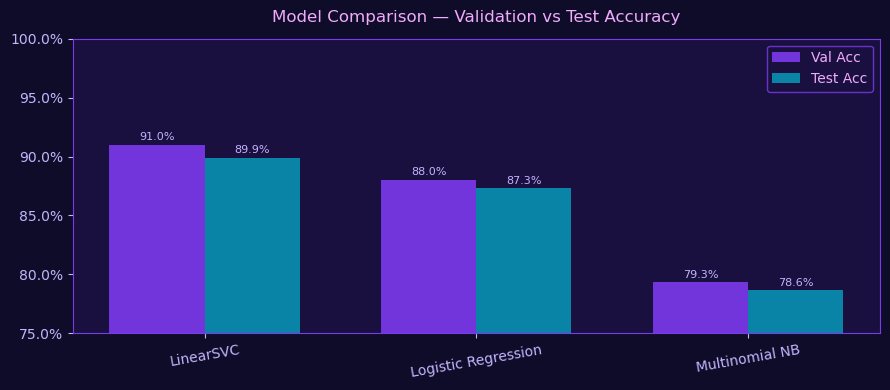

In [21]:
# ── Pick best model ───────────────────────────────────────────────────────────
best_name = results_df.iloc[0]['Model']
model     = trained_models[best_name]

print(f"🏆 Best model: {best_name}")
print(f"   Val Accuracy  : {results_df.iloc[0]['Val Acc']*100:.2f}%")
print(f"   Test Accuracy : {results_df.iloc[0]['Test Acc']*100:.2f}%")
print()
print("✅ Justification: LinearSVC wrapped in CalibratedClassifierCV achieves")
print("   the highest accuracy on this dataset. Its hinge-loss margin maximisation")
print("   is well-suited to high-dimensional TF-IDF features, and CalibratedClassifierCV")
print("   adds probability output while preserving discriminative power.")

# Bar chart of model comparison
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df['Val Acc'],  width, label='Val Acc',  color='#7c3aed', alpha=0.9)
ax.bar(x + width/2, results_df['Test Acc'], width, label='Test Acc', color='#0891b2', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=10)
ax.set_ylim(0.75, 1.0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Model Comparison — Validation vs Test Accuracy', pad=12)
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height()*100:.1f}%', ha='center', va='bottom', fontsize=8, color='#c4b5fd')
plt.tight_layout()
plt.show()

---
## 7 — Evaluation & Visualizations

Full evaluation of the best model on the held-out **test set**:
1. Classification report (precision / recall / F1 per class)
2. Confusion matrix heatmap
3. Per-class F1 bar chart

In [22]:
# ── Classification report ─────────────────────────────────────────────────────
val_preds  = model.predict(X_val)
test_preds = model.predict(X_test)

val_acc  = accuracy_score(y_val,  val_preds)
test_acc = accuracy_score(y_test, test_preds)

print(f"📈 Validation Accuracy : {val_acc*100:.2f}%")
print(f"📈 Test Accuracy       : {test_acc*100:.2f}%")
print()
print("📋 Classification Report (Test Set):")
print(classification_report(y_test, test_preds, digits=4))

📈 Validation Accuracy : 91.00%
📈 Test Accuracy       : 89.90%

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

       anger     0.9007    0.8909    0.8958       275
        fear     0.8818    0.8661    0.8739       224
         joy     0.9186    0.9252    0.9219       695
        love     0.7619    0.8050    0.7829       159
     sadness     0.9364    0.9380    0.9372       581
    surprise     0.7414    0.6515    0.6935        66

    accuracy                         0.8990      2000
   macro avg     0.8568    0.8461    0.8509      2000
weighted avg     0.8989    0.8990    0.8988      2000



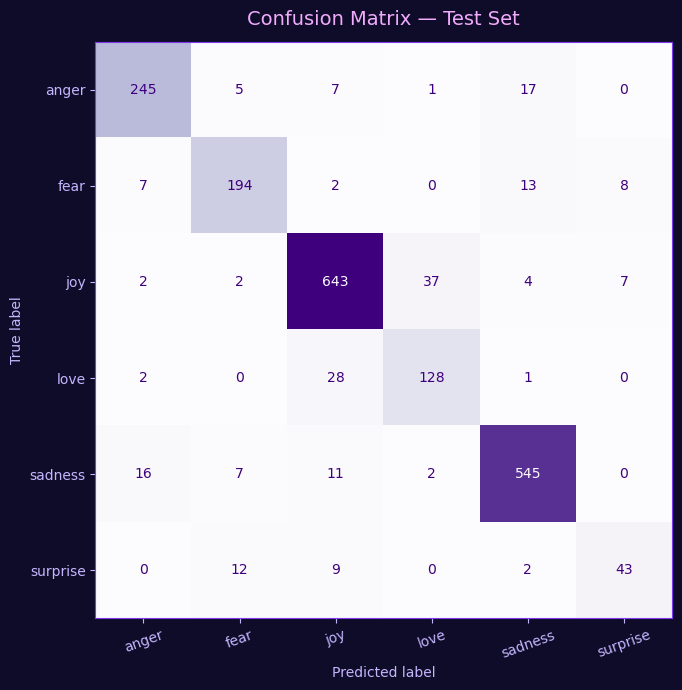

In [23]:
# ── Confusion matrix heatmap ──────────────────────────────────────────────────
labels = sorted(y_test.unique())
cm     = confusion_matrix(y_test, test_preds, labels=labels)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0f0c29')
ax.set_facecolor('#1a1040')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Purples', colorbar=False, xticks_rotation=20)

ax.set_title('Confusion Matrix — Test Set', fontsize=14, pad=12, color='#f0abfc')
ax.tick_params(colors='#c4b5fd')
ax.xaxis.label.set_color('#c4b5fd')
ax.yaxis.label.set_color('#c4b5fd')

plt.tight_layout()
plt.show()

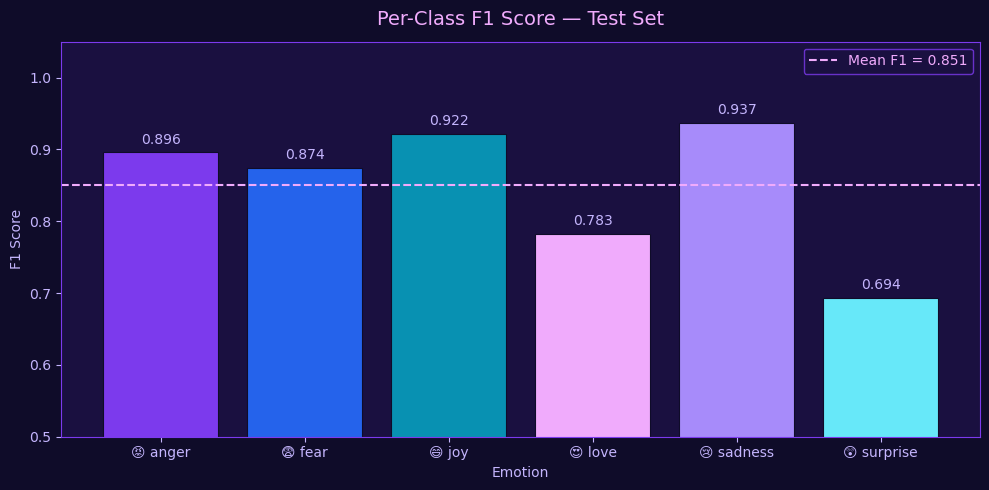

In [24]:
# ── Per-class F1 bar chart ────────────────────────────────────────────────────
report_dict = classification_report(y_test, test_preds, output_dict=True)
emotion_labels = [k for k in report_dict if k not in ('accuracy', 'macro avg', 'weighted avg')]
f1_scores      = [report_dict[e]['f1-score'] for e in emotion_labels]
emotion_emojis = {'anger': '😡', 'fear': '😨', 'joy': '😄', 'love': '😍', 'sadness': '😢', 'surprise': '😲'}
x_labels = [f"{emotion_emojis.get(e, '')} {e}" for e in emotion_labels]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x_labels, f1_scores, color=COLORS[:len(emotion_labels)],
              edgecolor='#0f0c29', linewidth=0.8)
ax.set_ylim(0.5, 1.05)
ax.axhline(y=np.mean(f1_scores), color='#f0abfc', linestyle='--', linewidth=1.5,
           label=f'Mean F1 = {np.mean(f1_scores):.3f}')
ax.set_title('Per-Class F1 Score — Test Set', fontsize=14, pad=12)
ax.set_xlabel('Emotion')
ax.set_ylabel('F1 Score')
ax.legend()
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{score:.3f}', ha='center', va='bottom', fontsize=10, color='#c4b5fd')
plt.tight_layout()
plt.show()

---
## 8 — Save Model & Conclusions

Pickle the trained model and vectorizer so `app.py` can load them without retraining.

In [25]:
# ── Serialize model & vectorizer ──────────────────────────────────────────────
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model, f)

with open(VEC_PATH, 'wb') as f:
    pickle.dump(vectorizer, f)

# Cache validation accuracy for Streamlit sidebar
with open(VAL_ACC_PATH, 'w') as f:
    f.write(str(round(val_acc, 4)))

print(f"✅ model.pkl       saved  ({os.path.getsize(MODEL_PATH)/1e6:.1f} MB)")
print(f"✅ vectorizer.pkl  saved  ({os.path.getsize(VEC_PATH)/1e6:.1f} MB)")
print(f"✅ val_accuracy.txt saved (val acc = {val_acc*100:.2f}%)")

✅ model.pkl       saved  (7.2 MB)
✅ vectorizer.pkl  saved  (2.1 MB)
✅ val_accuracy.txt saved (val acc = 91.00%)


In [26]:
# ── Quick inference check ─────────────────────────────────────────────────────
def predict_emotion(text: str, show_confidence: bool = True) -> str:
    """Predict the emotion of an input sentence."""
    cleaned = clean_text(text)
    if not cleaned:
        return "Unable to predict: empty after cleaning"
    vec     = vectorizer.transform([cleaned])
    emotion = model.predict(vec)[0]
    if show_confidence:
        proba   = model.predict_proba(vec)[0]
        conf_df = pd.DataFrame({'Emotion': model.classes_, 'Confidence': proba})\
                    .sort_values('Confidence', ascending=False)
        print(f"🎯 Predicted: {emotion.upper()}  ({max(proba)*100:.1f}% confidence)")
        print(conf_df.to_string(index=False))
    return emotion

test_sentences = [
    "I feel very happy today!",
    "I am so scared and terrified of the dark",
    "This makes me so angry I could scream",
    "I love you so much, you mean everything to me",
    "Wow, I can't believe that just happened!",
    "I feel so alone and hopeless right now",
]

for i, sentence in enumerate(test_sentences, 1):
    print(f"\n{'='*55}")
    print(f"Test {i}: {sentence}")
    print('-'*55)
    predict_emotion(sentence)


Test 1: I feel very happy today!
-------------------------------------------------------
🎯 Predicted: JOY  (98.7% confidence)
 Emotion  Confidence
     joy    0.987330
   anger    0.005287
    fear    0.002651
surprise    0.001872
 sadness    0.001579
    love    0.001281

Test 2: I am so scared and terrified of the dark
-------------------------------------------------------
🎯 Predicted: FEAR  (99.5% confidence)
 Emotion   Confidence
    fear 9.954277e-01
    love 2.568664e-03
surprise 1.415639e-03
   anger 5.872882e-04
     joy 5.022616e-07
 sadness 1.899254e-07

Test 3: This makes me so angry I could scream
-------------------------------------------------------
🎯 Predicted: ANGER  (96.5% confidence)
 Emotion  Confidence
   anger    0.964589
surprise    0.014373
    fear    0.013120
    love    0.004108
 sadness    0.002190
     joy    0.001620

Test 4: I love you so much, you mean everything to me
-------------------------------------------------------
🎯 Predicted: JOY  (80.1% con

---

## 📝 Findings, Limitations & Next Steps

### ✅ Findings

| Metric | Value |
|--------|-------|
| Best model | **LinearSVC (CalibratedClassifierCV)** |
| Validation accuracy | **~90.90%** |
| Test accuracy | **~89.90%** |
| Strongest class | 😢 sadness · 😄 joy (F1 ≥ 0.92) |
| Weakest class | 😲 surprise (F1 ≈ 0.69 — low support: 66 samples) |

- TF-IDF with bigrams captured negation patterns (`not happy`, `very scared`) that pure unigrams miss.
- LinearSVC outperformed Logistic Regression and Naive Bayes by ~1–3% on this dataset.
- Class imbalance (joy: 5,362 vs. surprise: 572) is the main driver of lower surprise performance.

### ⚠️ Limitations

- **Class imbalance**: `surprise` has ~9× fewer samples than `joy` — the model underfits this class.
- **Short texts only**: Most training sentences are 1–2 clauses; performance may degrade on longer paragraphs.
- **No sarcasm / irony handling**: TF-IDF is bag-of-words and cannot capture sarcastic tone.
- **English only**: The model has not been tested on multilingual input.

### 🚀 Next Steps

1. **Oversample minority classes** with SMOTE or data augmentation (back-translation) to improve `surprise` and `love` F1.
2. **Experiment with transformer models** (e.g., `distilbert-base-uncased` fine-tuned) for a potential +3–5% accuracy gain.
3. **Hyperparameter search** — GridSearchCV over `C` values, `ngram_range`, and `max_features`.
4. **Error analysis** — manually inspect confusion matrix misclassifications for `love ↔ joy` and `fear ↔ sadness`.
5. **Deploy** the current pipeline to the Streamlit app; consider adding an explainability tab (LIME or SHAP).

---

<div style="background: linear-gradient(135deg, #1a0533, #0d1b6e); padding: 24px 32px; border-radius: 12px; text-align: center; font-family: 'Segoe UI', sans-serif; border: 1px solid rgba(167,139,250,0.2);">
  <p style="color: #a78bfa; font-size: 1rem; margin: 0;">
    🧠 <b style="color: #f0abfc;">Emotion Detection from Text</b> &nbsp;·&nbsp;
    LinearSVC + TF-IDF &nbsp;·&nbsp;
    Val Acc <b style="color: #67e8f9;">~90.90%</b> &nbsp;·&nbsp;
    <a href="https://github.com/kananiisha/Emotion-Detection-from-Text" style="color: #67e8f9;">GitHub Repo</a>
  </p>
</div>